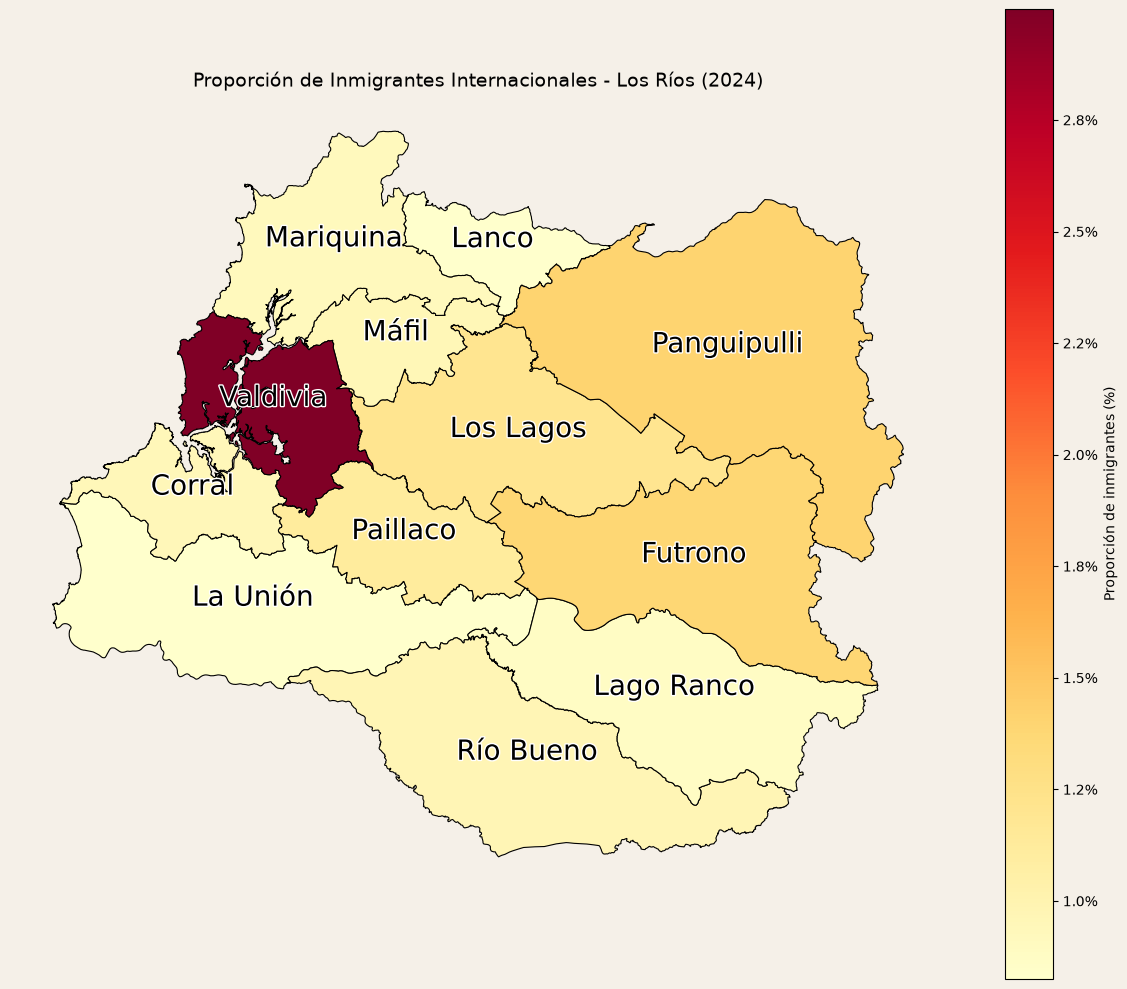

In [1]:
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
from matplotlib.colors import Normalize
from matplotlib.cm import ScalarMappable
import matplotlib.cm as cm
from matplotlib import patheffects
from pathlib import Path

# Carpeta donde está este notebook (funciona en Jupyter)
BASE = Path().resolve()

# ── Migración 2024 ─────────────────────────
df_mig = pd.read_csv(BASE / "migracion_2024.csv")
dfLosRios24 = df_mig[df_mig["Región"] == "Los Ríos"].copy()
dfLosRios24 = dfLosRios24[
    ~dfLosRios24["País o continente de nacimiento"]
    .str.contains("Total nacidos fuera del país", na=False)
]
migrantesComuna24 = dfLosRios24.groupby("Comuna")["Inmigrantes internacionales"].sum().reset_index()
migrantesComuna24.rename(columns={"Inmigrantes internacionales": "Migrantes"}, inplace=True)
migrantesComuna24["Comuna"] = migrantesComuna24["Comuna"].str.strip().str.title()

# ── Población 2024 ─────────────────────────
df_pob = pd.read_csv(BASE / "poblacion_2024.csv")
poblacion = df_pob[
    df_pob["Región de residencia habitual actual"] == "Los Ríos"
][["Comuna de residencia habitual actual", "Población censada"]].copy()
poblacion.rename(columns={
    "Comuna de residencia habitual actual": "Comuna",
    "Población censada": "Población"
}, inplace=True)
poblacion["Comuna"] = poblacion["Comuna"].str.strip().str.title()

# ── Proporción ─────────────────────────────
datos24 = pd.merge(migrantesComuna24, poblacion, on="Comuna", how="left")
datos24["Proporción (%)"] = (datos24["Migrantes"] / datos24["Población"]) * 100

# ── Shapefile ──────────────────────────────
gdf = gpd.read_file(BASE / "comunas.shp")
los_rios = gdf[gdf["codregion"] == 14].copy()
los_rios["Comuna"] = los_rios["Comuna"].str.strip().str.title()

mapa24 = los_rios.merge(datos24, on="Comuna", how="left")

# ── Graficar ───────────────────────────────
fig, ax = plt.subplots(figsize=(12, 10))
cmap = cm.YlOrRd
norm = Normalize(vmin=mapa24["Proporción (%)"].min(), vmax=mapa24["Proporción (%)"].max())

mapa24.plot(
    column="Proporción (%)",
    ax=ax,
    cmap=cmap,
    norm=norm,
    edgecolor="black",
    linewidth=0.8,
    missing_kwds={"color": "lightgrey", "label": "Sin datos"}
)
fig.patch.set_facecolor("#F5F0E8")

for _, row in mapa24.iterrows():
    centroid = row["geometry"].centroid
    ax.annotate(
        row["Comuna"],
        xy=(centroid.x, centroid.y),
        ha="center",
        fontsize=20,
        color="black",
        path_effects=[patheffects.withStroke(linewidth=2, foreground="white")]
    )

sm = ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([])
cbar = plt.colorbar(sm, ax=ax, label="Proporción de inmigrantes (%)")
cbar.ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"{x:.1f}%"))

ax.set_title("Proporción de Inmigrantes Internacionales - Los Ríos (2024)", fontsize=14)
ax.axis("off")
plt.tight_layout()
plt.show()
